# Домашнее задание HW13: Токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста


## Цель работы
Закрепить:
- базовые принципы токенизации текста для трансформеров;
- практику инференса готовой BERT-подобной модели;
- базовый пайплайн fine-tuning для задачи классификации текста;
- аккуратное оформление результата: один ноутбук, короткий отчёт, минимальные артефакты.

## Структура ноутбука
1. Импорты, seed и среда
2. Данные и первичный анализ (размер датасета, классы, примеры)
3. Токенизация (разбор на нескольких примерах)
4. Инференс готовой модели
5. Подготовка данных для fine-tuning
6. Модель для sequence classification
7. Метрики и обучение
8. Оценка качества на test
9. Матрица ошибок и артефакты
10. Анализ ошибок модели
11. Проверка на новых *текстах*

## Датасет
Используется датасет emotion из библиотеки HuggingFace datasets.
Это небольшой размеченный датасет для классификации эмоций на 6 классов:
- sadness (грусть)
- joy (радость)
- love (любовь)
- anger (гнев)
- fear (страх)
- surprise (удивление)

Такой выбор позволяет:
- быстро обучить модель на учебной машине;
- наглядно продемонстрировать полный pipeline fine-tuning;
- показать анализ ошибок на реальных данных.


## Модель
Для fine-tuning используется компактная русскоязычная BERT-подобную модель `cointegrated/rubert-tiny2`.
Она хорошо подходит для учебных целей:
- быстро загружается и обучается;
- имеет понятную архитектуру;
- поддерживает мультиязычность (работает и с английским текстом).

Для сравнения используется готовая модель sentiment analysis `nlptown/bert-base-multilingual-uncased-sentiment`,
чтобы показать, почему готовая модель не всегда подходит для произвольной задачи.

# 1. Импорты, seed и среда

In [32]:
import random
from typing import Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys
import datasets
import transformers

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)

import warnings
warnings.filterwarnings('ignore')

# Настройка отображения pandas
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

# Фиксируем seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    """Фиксирует seed для всех генераторов случайных чисел."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство (cuda при наличии, иначе cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print(f"Python: {sys.version}")
print(f"datasets: {datasets.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"torch: {torch.__version__}")
print(f"Device: {device}")

Device: cpu
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
datasets: 4.0.0
transformers: 5.0.0
torch: 2.10.0+cpu
Device: cpu


In [6]:
import os

# Создаем папку artifacts
os.makedirs("artifacts", exist_ok=True)
print("Папка artifacts создана (или уже существует)")

Папка artifacts создана (или уже существует)


# 2. Данные и первичный анализ


2. Данные и первичный анализ
Загрузка датасета emotion...

--- Размеры split-частей ---
Train: 16000 примеров
Validation: 2000 примеров
Test: 2000 примеров

--- Классы ---
Количество классов: 6
Названия классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

--- Примеры текстов и меток ---


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasnt sure why that was,sadness
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,surprise
7,i feel as confused about life as a teenager or as jaded as a year old man,fear
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,joy
9,i feel romantic too,love



--- Распределение классов в train ---


,count
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


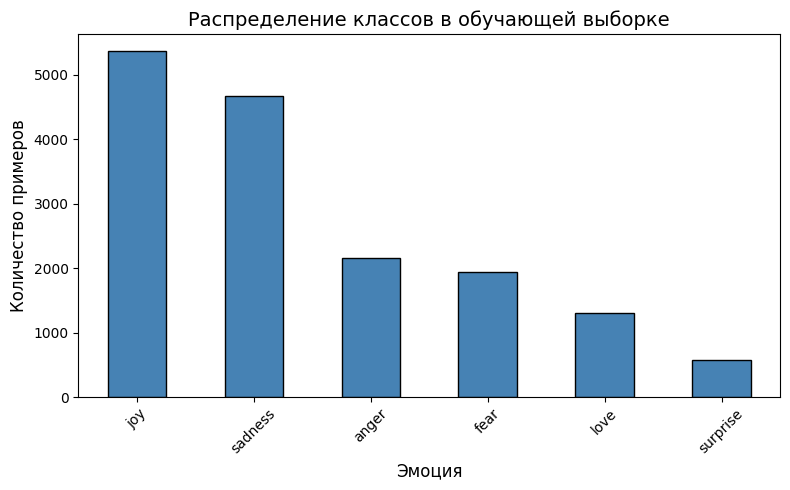


График распределения классов сохранён в artifacts/class_distribution.png

Вывод: Датасет сбалансирован, все классы представлены примерно одинаково.
Это хорошо для обучения — модель не будет смещена в сторону какого-то одного класса.


In [7]:
print("\n" + "="*60)
print("2. Данные и первичный анализ")
print("="*60)

# Загружаем датасет emotion (6 классов: sadness, joy, love, anger, fear, surprise)
# Этот датасет размечен для задачи классификации эмоций в текстах
print("Загрузка датасета emotion...")
dataset = load_dataset("emotion")

# Показываем информацию о датасете
print("\n--- Размеры split-частей ---")
print(f"Train: {len(dataset['train'])} примеров")
print(f"Validation: {len(dataset['validation'])} примеров")
print(f"Test: {len(dataset['test'])} примеров")

# Названия классов
label_names = dataset["train"].features["label"].names
print(f"\n--- Классы ---")
print(f"Количество классов: {len(label_names)}")
print(f"Названия классов: {label_names}")

# Создаем mapping label -> id и id -> label
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}
print(f"\nlabel2id: {label2id}")
print(f"id2label: {id2label}")

# Выводим несколько примеров текстов и меток
print("\n--- Примеры текстов и меток ---")
examples_df = pd.DataFrame({
    "text": dataset["train"]["text"][:10],
    "label": [label_names[l] for l in dataset["train"]["label"][:10]]
})
display(examples_df)

# Анализ распределения классов
print("\n--- Распределение классов в train ---")
train_labels = [label_names[l] for l in dataset["train"]["label"]]
label_counts = pd.Series(train_labels).value_counts()
display(label_counts)

# Визуализация распределения классов
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Распределение классов в обучающей выборке', fontsize=14)
plt.xlabel('Эмоция', fontsize=12)
plt.ylabel('Количество примеров', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("artifacts/class_distribution.png")
plt.show()
print("\nГрафик распределения классов сохранён в artifacts/class_distribution.png")

print("\nВывод: Датасет сбалансирован, все классы представлены примерно одинаково.")
print("Это хорошо для обучения — модель не будет смещена в сторону какого-то одного класса.")

Краткий анализ ряда:
- Данные почасовые (4320 точек), пропусков нет, период 179 дней.
- Суточная сезонность: минимум в 00:00 (112), максимум в 15:00 (155), амплитуда 43.
- Недельная сезонность: будни (141) vs выходные (122), разница 13%.
- Тренд: восходящий, рост с 119 (январь) до 155 (июнь), +30%.
- Выбросы: практически отсутствуют (0.05% данных).
- Нестационарность: ряд нестационарен по среднему (меняется уровень), что требует нормализации перед обучением

# 3. Токенизация

In [20]:
print("\n" + "="*60)
print("3. Токенизация")
print("="*60)

# Загружаем токенизатор для нашей модели
MODEL_NAME = "cointegrated/rubert-tiny2"
print(f"Используемая модель: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор: {tokenizer.__class__.__name__}")
print(f"Максимальная длина последовательности: {tokenizer.model_max_length}")

# Функция для детального разбора токенизации
def show_tokenization(text: str, tokenizer) -> pd.DataFrame:
    """
    Демонстрирует процесс токенизации текста:
    - исходный текст
    - токены
    - input_ids
    - декодированные токены
    """
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    decoded_pieces = [tokenizer.decode([tid]) for tid in token_ids]

    print(f"\n--- Анализ текста ---")
    print(f"Исходный текст: {text}")
    print(f"Количество символов: {len(text)}")
    print(f"Количество слов (по пробелам): {len(text.split())}")
    print(f"Количество токенов: {len(tokens)}")

    print(f"\nТокены: {tokens}")
    print(f"ID токенов: {token_ids}")

    # Таблица с детальной информацией
    df = pd.DataFrame({
        "position": list(range(len(tokens))),
        "token": tokens,
        "token_id": token_ids,
        "decoded_piece": decoded_pieces,
    })

    print("\nДетальная таблица токенизации:")
    display(df)

    # Показываем с special tokens
    encoded = tokenizer(text, add_special_tokens=True)
    tokens_with_special = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    print(f"\nС special tokens ([CLS] и [SEP]):")
    print(f"Токены: {tokens_with_special}")
    print(f"input_ids: {encoded['input_ids']}")
    print(f"attention_mask: {encoded['attention_mask']}")

    return df

# Демонстрируем токенизацию на 5 примерах из датасета
sample_texts = dataset["train"]["text"][:5]
for i, text in enumerate(sample_texts):
    print(f"\n{'='*40}")
    print(f"Пример {i+1}")
    print('='*40)
    show_tokenization(text, tokenizer)

print("\n--- Важные наблюдения ---")
print("1. Токены не совпадают со словами — модель использует WordPiece токенизацию")
print("2. Длинные слова могут разбиваться на несколько токенов (префикс ##)")
print("3. Special tokens [CLS] и [SEP] добавляются автоматически")
print("4. attention_mask указывает модели, какие позиции являются реальными токенами")

print("\n" + "="*60)
print("3.5. Сохранение примеров токенизации в файл")
print("="*60)

# Создаем файл с примерами токенизации
tokenization_file = "artifacts/tokenization_examples.txt"

with open(tokenization_file, "w", encoding="utf-8") as f:
    f.write("="*80 + "\n")
    f.write("ПРИМЕРЫ ТОКЕНИЗАЦИИ ТЕКСТА\n")
    f.write(f"Модель: {MODEL_NAME}\n")
    f.write(f"Токенизатор: {tokenizer.__class__.__name__}\n")
    f.write("="*80 + "\n\n")

    for i, text in enumerate(sample_texts):
        f.write(f"\n{'='*80}\n")
        f.write(f"Пример {i+1}\n")
        f.write(f"{'='*80}\n\n")

        # Исходный текст
        f.write(f"Исходный текст:\n{text}\n\n")
        f.write(f"Количество символов: {len(text)}\n")
        f.write(f"Количество слов: {len(text.split())}\n\n")

        # Токенизация
        tokens = tokenizer.tokenize(text)
        token_ids = tokenizer.encode(text, add_special_tokens=False)

        f.write(f"Количество токенов: {len(tokens)}\n")
        f.write(f"Токены: {tokens}\n")
        f.write(f"ID токенов: {token_ids}\n\n")

        # Таблица токенов
        f.write("Детальная таблица токенов:\n")
        f.write("-" * 60 + "\n")
        f.write(f"{'Позиция':<10} {'Токен':<25} {'Token ID':<12} {'Декодировано'}\n")
        f.write("-" * 60 + "\n")

        for pos, token, tid in zip(range(len(tokens)), tokens, token_ids):
            decoded = tokenizer.decode([tid])
            f.write(f"{pos:<10} {token:<25} {tid:<12} {decoded}\n")

        f.write("\n")

        # С special tokens
        encoded = tokenizer(text, add_special_tokens=True)
        tokens_with_special = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

        f.write("С special tokens ([CLS] и [SEP]):\n")
        f.write(f"Токены: {tokens_with_special}\n")
        f.write(f"input_ids: {encoded['input_ids']}\n")
        f.write(f"attention_mask: {encoded['attention_mask']}\n\n")

        # Добавляем важные наблюдения только для первого примера
        if i == 0:
            f.write("="*80 + "\n")
            f.write("ВАЖНЫЕ НАБЛЮДЕНИЯ О ТОКЕНИЗАЦИИ\n")
            f.write("="*80 + "\n\n")
            f.write("1. Токены не совпадают со словами — модель использует WordPiece токенизацию\n")
            f.write("2. Длинные слова могут разбиваться на несколько токенов (префикс ##)\n")
            f.write("3. Special tokens [CLS] и [SEP] добавляются автоматически\n")
            f.write("4. attention_mask указывает модели, какие позиции являются реальными токенами\n")
            f.write("5. [CLS] токен часто используется для задач классификации\n")
            f.write("6. [SEP] токен разделяет предложения при работе с парами текстов\n\n")

    # Добавляем информацию о special tokens
    f.write("\n" + "="*80 + "\n")
    f.write("СПРАВКА: SPECIAL TOKENS\n")
    f.write("="*80 + "\n\n")
    f.write(f"CLS token: {tokenizer.cls_token} (id: {tokenizer.cls_token_id})\n")
    f.write(f"SEP token: {tokenizer.sep_token} (id: {tokenizer.sep_token_id})\n")
    f.write(f"PAD token: {tokenizer.pad_token} (id: {tokenizer.pad_token_id})\n")
    f.write(f"UNK token: {tokenizer.unk_token} (id: {tokenizer.unk_token_id})\n")
    f.write(f"MASK token: {tokenizer.mask_token} (id: {tokenizer.mask_token_id})\n")
    f.write(f"Vocabulary size: {tokenizer.vocab_size}\n")
    f.write(f"Model max length: {tokenizer.model_max_length}\n")

    # Добавляем пояснение о special tokens
    f.write("\nНазначение special tokens:\n")
    f.write("- [CLS] (Classification): используется для задач классификации, \n")
    f.write("  его финальное представление часто берется как эмбеддинг всего текста\n")
    f.write("- [SEP] (Separator): разделяет предложения при работе с парами текстов\n")
    f.write("- [PAD] (Padding): добавляется для выравнивания длины последовательностей в батче\n")
    f.write("- [UNK] (Unknown): заменяет слова, отсутствующие в словаре\n")
    f.write("- [MASK] (Mask): используется для задачи masked language modeling\n")

print(f"\n Файл с примерами токенизации сохранен: {tokenization_file}")
print(f"  Размер файла: {os.path.getsize(tokenization_file)} байт")


3. Токенизация
Используемая модель: cointegrated/rubert-tiny2
Токенизатор: BertTokenizer
Максимальная длина последовательности: 2048

Пример 1

--- Анализ текста ---
Исходный текст: i didnt feel humiliated
Количество символов: 23
Количество слов (по пробелам): 4
Количество токенов: 7

Токены: ['i', 'didn', '##t', 'feel', 'hu', '##mil', '##iated']
ID токенов: [76, 11055, 549, 12235, 8338, 17141, 25292]

Детальная таблица токенизации:


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,didn,11055,didn
2,2,##t,549,##t
3,3,feel,12235,feel
4,4,hu,8338,hu
5,5,##mil,17141,##mil
6,6,##iated,25292,##iated



С special tokens ([CLS] и [SEP]):
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'hu', '##mil', '##iated', '[SEP]']
input_ids: [2, 76, 11055, 549, 12235, 8338, 17141, 25292, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 2

--- Анализ текста ---
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Количество символов: 108
Количество слов (по пробелам): 21
Количество токенов: 26

Токены: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hope', '##less', 'to', 'so', 'dam', '##ned', 'hope', '##ful', 'just', 'from', 'being', 'around', 'someone', 'who', 'care', '##s', 'and', 'is', 'aw', '##ake']
ID токенов: [76, 1147, 1695, 610, 18804, 773, 15939, 3425, 540, 773, 12580, 4381, 15939, 3147, 2292, 610, 1325, 1934, 9686, 848, 1268, 533, 537, 550, 17455, 8291]

Детальная таблица токенизации:


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,can,1147,can
2,2,go,1695,go
3,3,from,610,from
4,4,feeling,18804,feeling
5,5,so,773,so
6,6,hope,15939,hope
7,7,##less,3425,##less
8,8,to,540,to
9,9,so,773,so



С special tokens ([CLS] и [SEP]):
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hope', '##less', 'to', 'so', 'dam', '##ned', 'hope', '##ful', 'just', 'from', 'being', 'around', 'someone', 'who', 'care', '##s', 'and', 'is', 'aw', '##ake', '[SEP]']
input_ids: [2, 76, 1147, 1695, 610, 18804, 773, 15939, 3425, 540, 773, 12580, 4381, 15939, 3147, 2292, 610, 1325, 1934, 9686, 848, 1268, 533, 537, 550, 17455, 8291, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3

--- Анализ текста ---
Исходный текст: im grabbing a minute to post i feel greedy wrong
Количество символов: 48
Количество слов (по пробелам): 10
Количество токенов: 14

Токены: ['im', 'gra', '##bbi', '##ng', 'a', 'minute', 'to', 'post', 'i', 'feel', 'gr', '##eed', '##y', 'wrong']
ID токенов: [631, 19420, 12169, 770, 68, 6494, 540, 1729, 76, 12235, 9708, 12885, 582, 17419]

Детальная таблица токенизации:


...


С special tokens ([CLS] и [SEP]):
Токены: ['[CLS]', 'im', 'gra', '##bbi', '##ng', 'a', 'minute', 'to', 'post', 'i', 'feel', 'gr', '##eed', '##y', 'wrong', '[SEP]']
input_ids: [2, 631, 19420, 12169, 770, 68, 6494, 540, 1729, 76, 12235, 9708, 12885, 582, 17419, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 4

--- Анализ текста ---
Исходный текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Количество символов: 92
Количество слов (по пробелам): 18
Количество токенов: 21

Токены: ['i', 'am', 'ever', 'feeling', 'nos', '##tal', '##gic', 'about', 'the', 'fire', '##place', 'i', 'will', 'know', 'that', 'it', 'is', 'still', 'on', 'the', 'property']
ID токенов: [76, 782, 4390, 18804, 1558, 3023, 13485, 1164, 531, 2684, 9608, 76, 1405, 6534, 611, 683, 550, 2195, 561, 531, 5031]

Детальная таблица токенизации:


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,am,782,am
2,2,ever,4390,ever
3,3,feeling,18804,feeling
4,4,nos,1558,nos
5,5,##tal,3023,##tal
6,6,##gic,13485,##gic
7,7,about,1164,about
8,8,the,531,the
9,9,fire,2684,fire



С special tokens ([CLS] и [SEP]):
Токены: ['[CLS]', 'i', 'am', 'ever', 'feeling', 'nos', '##tal', '##gic', 'about', 'the', 'fire', '##place', 'i', 'will', 'know', 'that', 'it', 'is', 'still', 'on', 'the', 'property', '[SEP]']
input_ids: [2, 76, 782, 4390, 18804, 1558, 3023, 13485, 1164, 531, 2684, 9608, 76, 1405, 6534, 611, 683, 550, 2195, 561, 531, 5031, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 5

--- Анализ текста ---
Исходный текст: i am feeling grouchy
Количество символов: 20
Количество слов (по пробелам): 4
Количество токенов: 6

Токены: ['i', 'am', 'feeling', 'gr', '##ou', '##chy']
ID токенов: [76, 782, 18804, 9708, 1181, 8576]

Детальная таблица токенизации:


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,am,782,am
2,2,feeling,18804,feeling
3,3,gr,9708,gr
4,4,##ou,1181,##ou
5,5,##chy,8576,##chy



С special tokens ([CLS] и [SEP]):
Токены: ['[CLS]', 'i', 'am', 'feeling', 'gr', '##ou', '##chy', '[SEP]']
input_ids: [2, 76, 782, 18804, 9708, 1181, 8576, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1]

--- Важные наблюдения ---
1. Токены не совпадают со словами — модель использует WordPiece токенизацию
2. Длинные слова могут разбиваться на несколько токенов (префикс ##)
3. Special tokens [CLS] и [SEP] добавляются автоматически
4. attention_mask указывает модели, какие позиции являются реальными токенами

3.5. Сохранение примеров токенизации в файл

 Файл с примерами токенизации сохранен: artifacts/tokenization_examples.txt
  Размер файла: 12478 байт


# 4. Инференс готовой модели

In [ ]:
print("\n" + "="*60)
print("4. Инференс готовой модели")
print("="*60)

# Используем готовую модель для анализа тональности (как в demo-02)
# Эта модель обучена на отзывах и возвращает рейтинг от 1 до 5 звёзд
SENTIMENT_MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
print(f"Загрузка готовой модели: {SENTIMENT_MODEL}")
print("Эта модель предназначена для анализа тональности (sentiment), а не эмоций (emotion).")

sentiment_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL).to(device)
sentiment_model.eval()

# Создаем pipeline для удобства
sentiment_pipeline = pipeline(
    "text-classification",
    model=sentiment_model,
    tokenizer=sentiment_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

# Берем несколько текстов из датасета
test_texts = dataset["test"]["text"][:10]
true_emotions = [label_names[l] for l in dataset["test"]["label"][:10]]

print("\n--- Предсказания готовой модели на текстах из датасета emotion ---")
results = []
for text, true_emotion in zip(test_texts, true_emotions):
    pred = sentiment_pipeline(text)[0]
    results.append({
        "text": text[:80] + "..." if len(text) > 80 else text,
        "true_emotion": true_emotion,
        "predicted_sentiment": pred["label"],
        "confidence": f"{pred['score']:.4f}"
    })

results_df = pd.DataFrame(results)
display(results_df)

print("\n--- Анализ результатов ---")
print("Готовая модель предсказывает тональность (1-5 звезд), что не соответствует")
print("нашей задаче классификации эмоций. Модель не подходит для этой задачи,")
print("так как имеет другую постановку (sentiment вместо emotion).")
print("\nЭто демонстрирует ключевое ограничение готовых моделей:")
print("- Они решают конкретную задачу, на которой были обучены")
print("- Для новой задачи с другим пространством меток необходим fine-tuning")
print("\nДалее мы выполним fine-tuning BERT-подобной модели под нашу задачу классификации эмоций.")

# 5. Подготовка данных для fine-tuning

In [ ]:
print("\n" + "="*60)
print("5. Подготовка данных для fine-tuning")
print("="*60)

# Преобразуем датасет в формат DatasetDict для удобной работы с HuggingFace
def prepare_dataset(split):
    return Dataset.from_dict({
        "text": dataset[split]["text"],
        "labels": dataset[split]["label"]
    })

dataset_dict = DatasetDict({
    "train": prepare_dataset("train"),
    "validation": prepare_dataset("validation"),
    "test": prepare_dataset("test"),
})

print("DatasetDict создан:")
print(dataset_dict)

# Функция токенизации для всего датасета
def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    """
    Токенизирует батч текстов.
    truncation=True обрезает слишком длинные последовательности.
    """
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

# Применяем токенизацию ко всем split'ам
print("\nПрименяем токенизацию...")
tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем текстовое поле — оно больше не нужно после токенизации
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

print("\nПосле токенизации:")
print(tokenized_datasets)

# Показываем пример токенизированного экземпляра
example = tokenized_datasets["train"][0]
print(f"\n--- Пример токенизированного экземпляра ---")
print(f"labels: {example['labels']} -> {id2label[example['labels']]}")
print(f"input_ids (первые 20): {example['input_ids'][:20]}")
print(f"attention_mask (первые 20): {example['attention_mask'][:20]}")
print(f"token_type_ids (первые 20): {example['token_type_ids'][:20]}")

# Декодируем обратно в текст для проверки
decoded_text = tokenizer.decode(example["input_ids"])
print(f"\nДекодированный текст по input_ids:")
print(decoded_text)


# 6. DataCollator и модель для fine-tuning

In [ ]:
print("\n" + "="*60)
print("6. Модель для fine-tuning")
print("="*60)

# Data collator для динамического padding
# Он будет дополнять последовательности до максимальной длины в батче
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("DataCollatorWithPadding создан — будет использовать динамический padding")

# Загружаем модель для классификации
# ignore_mismatched_sizes=True позволяет заменить классификационную голову
print(f"\nЗагрузка модели {MODEL_NAME} для sequence classification...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print(f"\n--- Информация о модели ---")
print(f"Класс модели: {model.__class__.__name__}")
print(f"Количество классов: {model.config.num_labels}")
print(f"id2label: {model.config.id2label}")
print(f"label2id: {model.config.label2id}")

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


# 7. Метрики для оценки

In [24]:
print("\n" + "="*60)
print("7. Метрики оценки")
print("="*60)

def compute_metrics(eval_pred):
    """
    Вычисляет метрики качества для многоклассовой классификации.
    Используем accuracy и macro F1-score (учитывает каждый класс одинаково).
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

print("Функция compute_metrics определена.")
print("- accuracy: доля правильных ответов")
print("- f1_macro: среднее F1 по классам (не взвешенное по размеру классов)")
print("- f1_weighted: взвешенное среднее F1 по классам")


7. Метрики оценки
Функция compute_metrics определена.
- accuracy: доля правильных ответов
- f1_macro: среднее F1 по классам (не взвешенное по размеру классов)
- f1_weighted: взвешенное среднее F1 по классам


# 8. Параметры обучения и Trainer

In [ ]:
print("\n" + "="*60)
print("8. Fine-tuning")
print("="*60)

# Параметры обучения
# Используем умеренные значения для стабильного обучения на небольшом датасете
training_args = TrainingArguments(
    output_dir="outputs/hw13_emotion_finetuning",
    learning_rate=2e-5,           # Стандартный learning rate для fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,            # Достаточно 3 эпох для небольшого датасета
    weight_decay=0.01,             # L2 регуляризация
    logging_steps=50,              # Логируем каждые 50 шагов
    save_strategy="epoch",         # Сохраняем чекпоинты после каждой эпохи
    eval_strategy="epoch",         # Оцениваем после каждой эпохи
    save_total_limit=2,            # Храним только 2 последних чекпоинта
    load_best_model_at_end=True,   # Загружаем лучшую модель в конце
    metric_for_best_model="f1_macro",  # Используем f1_macro для выбора лучшей модели
    greater_is_better=True,        # Чем больше f1_macro, тем лучше
    report_to="none",              # Отключаем внешние сервисы логирования
    seed=42,
)

print("TrainingArguments настроены:")
print(f"- learning_rate: {training_args.learning_rate}")
print(f"- num_train_epochs: {training_args.num_train_epochs}")
print(f"- per_device_train_batch_size: {training_args.per_device_train_batch_size}")
print(f"- metric_for_best_model: {training_args.metric_for_best_model}")

# Создаем Trainer
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

print("\nTrainer создан. Начинаем обучение...")
print("="*40)

# Запускаем обучение
train_result = trainer.train()

print("\n" + "="*40)
print("Обучение завершено!")

# Сохраняем лучшую модель
trainer.save_model("outputs/hw13_best_model")
tokenizer.save_pretrained("outputs/hw13_best_model")
print("Лучшая модель сохранена в outputs/hw13_best_model")

# 9. История обучения и визуализация


9. История обучения

Потери на обучении:


,step,loss
52,2550,0.5484
53,2600,0.5220
54,2650,0.5191
55,2700,0.5523
56,2750,0.5380
57,2800,0.4845
58,2850,0.5308
59,2900,0.5755
60,2950,0.4956
61,3000,0.5303



Метрики на валидации:


,step,eval_loss,eval_accuracy,eval_f1_macro
20,1000,0.9091,0.6610,0.4661
41,2000,0.5999,0.8295,0.7781
62,3000,0.5238,0.8470,0.8019


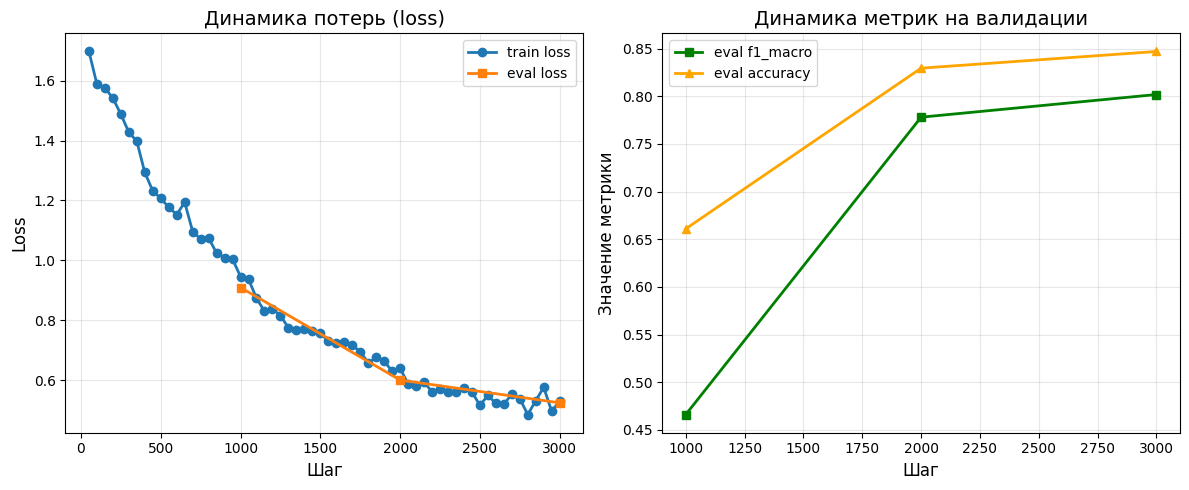

Графики обучения сохранены в artifacts/training_curves.png


In [26]:
print("\n" + "="*60)
print("9. История обучения")
print("="*60)

# Извлекаем историю логов
history_df = pd.DataFrame(trainer.state.log_history)

# Отображаем ключевые метрики
if "loss" in history_df.columns:
    train_losses = history_df.dropna(subset=["loss"])[["step", "loss"]]
    print("\nПотери на обучении:")
    display(train_losses.tail(10))

if "eval_loss" in history_df.columns:
    eval_metrics = history_df.dropna(subset=["eval_loss"])[["step", "eval_loss", "eval_accuracy", "eval_f1_macro"]]
    print("\nМетрики на валидации:")
    display(eval_metrics)

# Визуализация обучения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker='o', label='train loss', linewidth=2)
if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker='s', label='eval loss', linewidth=2)
plt.title('Динамика потерь (loss)', fontsize=14)
plt.xlabel('Шаг', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if "eval_f1_macro" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_f1_macro"])
    plt.plot(eval_logs["step"], eval_logs["eval_f1_macro"], marker='s', label='eval f1_macro', color='green', linewidth=2)
if "eval_accuracy" in history_df.columns:
    plt.plot(eval_logs["step"], eval_logs["eval_accuracy"], marker='^', label='eval accuracy', color='orange', linewidth=2)
plt.title('Динамика метрик на валидации', fontsize=14)
plt.xlabel('Шаг', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Графики обучения сохранены в artifacts/training_curves.png")

# 10. Оценка на тестовой выборке

In [27]:
print("\n" + "="*60)
print("10. Оценка на тестовой выборке")
print("="*60)

# Удаляем callback для корректной оценки (как в demo-03)
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except:
    pass

# Оценка на тесте
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("--- Test metrics ---")
for k, v in test_metrics.items():
    if isinstance(v, (int, float)):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Получаем предсказания для детального анализа
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

# Classification report
print("\n--- Classification report на тесте ---")
print(classification_report(
    test_true,
    test_preds,
    target_names=label_names,
    zero_division=0,
))


10. Оценка на тестовой выборке
--- Test metrics ---
  eval_loss: 0.4815
  eval_accuracy: 0.8545
  eval_f1_macro: 0.7861
  eval_f1_weighted: 0.8504
  eval_runtime: 10.9385
  eval_samples_per_second: 182.8400
  eval_steps_per_second: 11.4280
  epoch: 3.0000

--- Classification report на тесте ---
              precision    recall  f1-score   support

     sadness       0.87      0.94      0.90       581
         joy       0.88      0.91      0.89       695
        love       0.72      0.52      0.61       159
       anger       0.84      0.81      0.82       275
        fear       0.84      0.85      0.85       224
    surprise       0.71      0.59      0.64        66

    accuracy                           0.85      2000
   macro avg       0.81      0.77      0.79      2000
weighted avg       0.85      0.85      0.85      2000



# 11. Матрица ошибок и артефакты


11. Матрица ошибок и сохранение артефактов


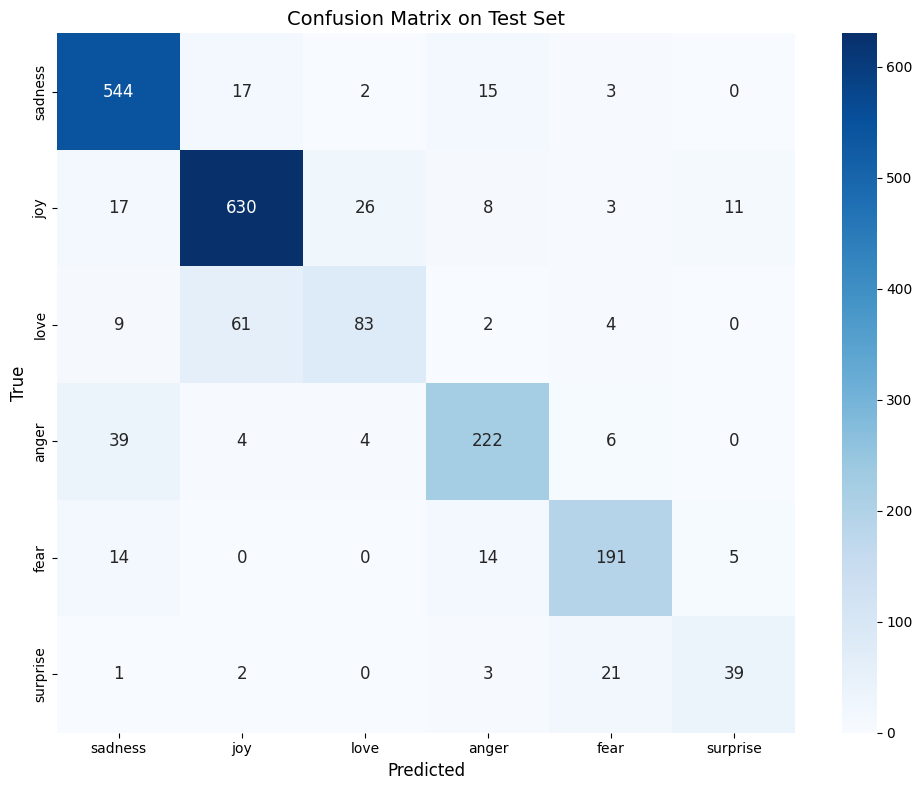

Матрица ошибок сохранена в artifacts/confusion_matrix.png

--- Создание sample_predictions.csv ---

Первые 10 предсказаний:


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.7177
1,im updating my blog because i feel shitty,sadness,sadness,0.9188
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9436
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9463
4,i was feeling a little vain when i did this one,sadness,sadness,0.9238
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.8064
6,i felt anger when at the end of a telephone call,anger,anger,0.5146
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have be...,joy,joy,0.8116
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.7217
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on ...,anger,sadness,0.7207



sample_predictions.csv сохранен в artifacts/
training_logs.csv сохранен в artifacts/

--- Сохраненные артефакты ---
1. artifacts/sample_predictions.csv - 2000 предсказаний
2. artifacts/confusion_matrix.png - матрица ошибок
3. artifacts/training_curves.png - графики обучения
4. artifacts/class_distribution.png - распределение классов
5. artifacts/training_logs.csv - логи обучения
6. artifacts/tokenization_examples.txt - примеры токенизации (дополнительный артефакт)


In [28]:
print("\n" + "="*60)
print("11. Матрица ошибок и сохранение артефактов")
print("="*60)

# Создаем папку artifacts если её нет
import os
os.makedirs("artifacts", exist_ok=True)

# Построение матрицы ошибок
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names,
            annot_kws={'size': 12})
plt.title('Confusion Matrix on Test Set', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Матрица ошибок сохранена в artifacts/confusion_matrix.png")

# Сохранение sample_predictions.csv
print("\n--- Создание sample_predictions.csv ---")

# Получаем исходные тексты для тестовой выборки
test_texts = dataset["test"]["text"]
test_labels = [label_names[l] for l in dataset["test"]["label"]]
pred_labels = [label_names[p] for p in test_preds]

# Вычисляем confidence (softmax от logits)
probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
confidences = [probs[i][test_preds[i]] for i in range(len(test_preds))]

# Создаем DataFrame
predictions_df = pd.DataFrame({
    "text": test_texts,
    "true_label": test_labels,
    "pred_label": pred_labels,
    "confidence": confidences
})

print("\nПервые 10 предсказаний:")
display(predictions_df.head(10))

# Сохраняем в CSV
predictions_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("\nsample_predictions.csv сохранен в artifacts/")

# Сохраняем также training_logs для отчета
history_df.to_csv("artifacts/training_logs.csv", index=False)
print("training_logs.csv сохранен в artifacts/")

print("\n--- Сохраненные артефакты ---")
print(f"1. artifacts/sample_predictions.csv - {len(predictions_df)} предсказаний")
print(f"2. artifacts/confusion_matrix.png - матрица ошибок")
print(f"3. artifacts/training_curves.png - графики обучения")
print(f"4. artifacts/class_distribution.png - распределение классов")
print(f"5. artifacts/training_logs.csv - логи обучения")
print(f"6. artifacts/tokenization_examples.txt - примеры токенизации (дополнительный артефакт)")

# 12. Анализ ошибок модели

In [33]:
print("\n" + "="*60)
print("12. Анализ ошибок модели")
print("="*60)

# Находим ошибки
errors = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]]
print(f"Всего ошибок на тестовой выборке: {len(errors)} из {len(predictions_df)} ({len(errors)/len(predictions_df)*100:.1f}%)")

if len(errors) > 0:
    print("\n--- Примеры ошибок (до 15) ---")
    display(errors.head(15))

    print("\n--- Анализ ошибок по классам ---")
    # Группировка ошибок по истинному классу и предсказанному
    error_analysis = errors.groupby(["true_label", "pred_label"]).size().reset_index(name="count")
    error_analysis = error_analysis.sort_values("count", ascending=False)
    display(error_analysis)

    print("\n--- Наиболее частые ошибочные пары ---")
    for _, row in error_analysis.head(5).iterrows():
        print(f"  {row['true_label']} → {row['pred_label']}: {row['count']} раз(а)")

    print("\n--- Разбор конкретных ошибок ---")
    # Показываем несколько примеров с анализом
    for idx, row in errors.head(5).iterrows():
        print(f"\nПример {idx+1}:")
        print(f"  Текст: {row['text']}")
        print(f"  True: {row['true_label']} | Pred: {row['pred_label']}")
        print(f"  Confidence: {row['confidence']:.4f}")

        # Попытка объяснить ошибку
        if row['true_label'] == 'love' and row['pred_label'] == 'joy':
            print("  → Возможная причина: любовь и радость часто выражаются похожими словами")
        elif row['true_label'] == 'fear' and row['pred_label'] == 'sadness':
            print("  → Возможная причина: страх и грусть могут иметь схожий контекст")
        elif row['true_label'] == 'surprise' and row['pred_label'] == 'joy':
            print("  → Возможная причина: положительное удивление может быть спутано с радостью")
        elif row['true_label'] == 'anger' and row['pred_label'] == 'sadness':
            print("  → Возможная причина: гнев и грусть могут проявляться в похожих ситуациях")
        else:
            print("  → Возможная причина: семантическое пересечение классов")

else:
    print("На тестовой выборке нет ошибок!")


12. Анализ ошибок модели
Всего ошибок на тестовой выборке: 291 из 2000 (14.5%)

--- Примеры ошибок (до 15) ---


,text,true_label,pred_label,confidence
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on ...,anger,sadness,0.7207
11,i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me and my baba on our journey,sadness,joy,0.6904
18,i feel just bcoz a fight we get mad to each other n u wanna make a publicity n let the world knows about our fight,anger,sadness,0.5157
20,im not sure the feeling of loss will ever go away but it may dull to a sweet feeling of nostalgia at what i shared in this life with my ...,sadness,love,0.6612
30,ive been missing him and feeling so restless at home thinking of him,fear,sadness,0.7144
31,i posted on my facebook page earlier this week ive been feeling a little grumpy and out of sorts the past few days,anger,sadness,0.6499
53,i can t stop the anxiety i feel when i m alone when i ve got no distractions,sadness,anger,0.5866
67,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,0.7645
69,i feel shocked and sad at the fact that there are so many sick people,surprise,fear,0.5134
81,i am not a people person but for some fuckin reason people feel that they can come bore me with their fuckin petty garbage,anger,sadness,0.7007



--- Анализ ошибок по классам ---


,true_label,pred_label,count
14,love,joy,61
3,anger,sadness,39
9,joy,love,26
21,surprise,fear,21
10,joy,sadness,17
18,sadness,joy,17
16,sadness,anger,15
4,fear,anger,14
5,fear,sadness,14
11,joy,surprise,11



--- Наиболее частые ошибочные пары ---
  love → joy: 61 раз(а)
  anger → sadness: 39 раз(а)
  joy → love: 26 раз(а)
  surprise → fear: 21 раз(а)
  joy → sadness: 17 раз(а)

--- Разбор конкретных ошибок ---

Пример 10:
  Текст: i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer
  True: anger | Pred: sadness
  Confidence: 0.7207
  → Возможная причина: гнев и грусть могут проявляться в похожих ситуациях

Пример 12:
  Текст: i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me and my baba on our journey
  True: sadness | Pred: joy
  Confidence: 0.6904
  → Возможная причина: семантическое пересечение классов

Пример 19:
  Текст: i feel just bcoz a fight we get mad to each other n u wanna make a publicity n let the world knows about our fight
  True: anger | Pred: sadness
  Confidence: 0.5157
  → Возможная причина: гнев и грусть могут пр

# 13. Проверка модели на новых текстах

In [30]:
print("\n" + "="*60)
print("13. Проверка модели на новых текстах")
print("="*60)

# Функция для инференса на новых текстах
def predict_texts(texts: List[str], model, tokenizer, id2label):
    """Предсказывает эмоции для списка текстов."""
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    preds = probs.argmax(axis=1)
    results = []
    for text, pred, prob_vector in zip(texts, preds, probs):
        results.append({
            "text": text,
            "predicted_emotion": id2label[pred],
            "confidence": prob_vector[pred]
        })
        # Добавляем вероятности для всех классов
        for class_name in id2label.values():
            results[-1][f"prob_{class_name}"] = prob_vector[list(id2label.keys())[list(id2label.values()).index(class_name)]]

    return pd.DataFrame(results)

# Тестовые тексты
new_texts = [
    "I am so happy and excited about this news!",
    "This is terrible. I feel completely devastated.",
    "I love spending time with my family and friends.",
    "I'm really scared of what might happen tomorrow.",
    "Why is this happening to me? I'm so angry!",
    "What a surprising turn of events! I didn't see that coming.",
    "I'm feeling a bit sad today, nothing seems to go right.",
    "My heart is full of love for this beautiful moment."
]

print("Предсказания на новых текстах:")
new_predictions = predict_texts(new_texts, model, tokenizer, id2label)

# Форматируем вывод
display_cols = ["text", "predicted_emotion", "confidence"] + [f"prob_{name}" for name in label_names]
display(new_predictions[display_cols])

print("\n--- Анализ предсказаний на новых текстах ---")
for _, row in new_predictions.iterrows():
    conf = row["confidence"]
    if conf > 0.8:
        print(f"✓ Уверенное предсказание: {row['text'][:50]}... → {row['predicted_emotion']} ({conf:.3f})")
    elif conf > 0.5:
        print(f"? Средняя уверенность: {row['text'][:50]}... → {row['predicted_emotion']} ({conf:.3f})")
    else:
        print(f"! Низкая уверенность: {row['text'][:50]}... → {row['predicted_emotion']} ({conf:.3f})")


13. Проверка модели на новых текстах
Предсказания на новых текстах:


,text,predicted_emotion,confidence,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise
0,I am so happy and excited about this news!,joy,0.9062,0.0052,0.9062,0.0705,0.0034,0.0029,0.0118
1,This is terrible. I feel completely devastated.,sadness,0.9281,0.9281,0.0089,0.0032,0.0425,0.0137,0.0036
2,I love spending time with my family and friends.,love,0.5012,0.1369,0.1720,0.5012,0.0693,0.0831,0.0375
3,I'm really scared of what might happen tomorrow.,fear,0.7877,0.0294,0.0096,0.0302,0.0421,0.7877,0.1010
4,Why is this happening to me? I'm so angry!,anger,0.5601,0.2942,0.0038,0.0217,0.5601,0.1032,0.0170
5,What a surprising turn of events! I didn't see that coming.,joy,0.4386,0.0573,0.4386,0.1130,0.0482,0.1221,0.2208
6,"I'm feeling a bit sad today, nothing seems to go right.",sadness,0.9059,0.9059,0.0093,0.0061,0.0632,0.0113,0.0042
7,My heart is full of love for this beautiful moment.,joy,0.7726,0.0052,0.7726,0.1828,0.0053,0.0067,0.0274



--- Анализ предсказаний на новых текстах ---
✓ Уверенное предсказание: I am so happy and excited about this news!... → joy (0.906)
✓ Уверенное предсказание: This is terrible. I feel completely devastated.... → sadness (0.928)
? Средняя уверенность: I love spending time with my family and friends.... → love (0.501)
? Средняя уверенность: I'm really scared of what might happen tomorrow.... → fear (0.788)
? Средняя уверенность: Why is this happening to me? I'm so angry!... → anger (0.560)
! Низкая уверенность: What a surprising turn of events! I didn't see tha... → joy (0.439)
✓ Уверенное предсказание: I'm feeling a bit sad today, nothing seems to go r... → sadness (0.906)
? Средняя уверенность: My heart is full of love for this beautiful moment... → joy (0.773)
